In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.append(os.path.abspath(".."))

### Exploratory analysis over the dataset ###

In [2]:
from src.data.load_data import load_raw_data

df = load_raw_data("../data/raw/household_energy_data.csv")

df.head()

,EnergyRequestedFromGrid_kW_,VentilationAndAC_kW_,CentralHeating_kW_,Dishwasher_kW_,UnderFloorHeater_kW_,ElectricRadiator_kW_,HomeOffice_kW_,Fridge_kW_,CellarSumpPump_kW_,GarageDoor_kW_,...,humidity,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability,WeatherIcon
0,1.050950,0.044486,0.943780,0.051738,0.128603,0.192523,0.480419,0.183982,0.035902,0.032217,...,0.796711,10.107633,29.318396,1016.955924,9.221607,282.033228,0.003948,24.549165,0.0,clear-night
1,1.660929,0.106278,1.601274,0.067756,0.079729,0.714241,0.453632,0.170119,0.135345,0.091296,...,0.727770,10.078902,29.308458,1016.921713,9.414020,282.020673,0.127737,24.403508,0.0,clear-night
2,0.644778,0.030107,0.684197,0.045105,0.084948,0.111661,0.341030,0.129343,0.049824,0.239230,...,0.644462,10.102304,29.354421,1016.948835,9.189457,282.067483,0.074501,24.404930,0.0,clear-night
3,1.275505,0.010800,1.353088,0.212320,0.417966,0.082586,0.328042,0.014115,0.238401,0.043073,...,0.660882,10.007465,29.287903,1016.982698,9.231673,282.203506,0.059602,24.498523,0.0,clear-night
4,1.639350,0.057672,1.758195,0.251836,0.060453,0.811615,0.323993,0.027434,0.267990,0.147532,...,0.663234,10.101834,29.261638,1016.996281,9.230588,282.082666,0.054329,24.499965,0.0,clear-night


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50391 entries, 0 to 50390
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   EnergyRequestedFromGrid_kW_   50390 non-null  float64
 1   VentilationAndAC_kW_          50391 non-null  float64
 2   CentralHeating_kW_            50391 non-null  float64
 3   Dishwasher_kW_                50391 non-null  float64
 4   UnderFloorHeater_kW_          50391 non-null  float64
 5   ElectricRadiator_kW_          50391 non-null  float64
 6   HomeOffice_kW_                50390 non-null  float64
 7   Fridge_kW_                    50390 non-null  float64
 8   CellarSumpPump_kW_            50391 non-null  float64
 9   GarageDoor_kW_                50390 non-null  float64
 10  Oven_kW_                      50390 non-null  float64
 11  CeramicHob_kW_                50391 non-null  float64
 12  RadonLevel_Bqm3               50391 non-null  float64
 13  K

In [4]:
df['RadonLevel_Bqm3']               

0        1.815441
1        1.755928
2        1.854870
3        1.668039
4        1.563025
           ...   
50386    2.205667
50387    2.150638
50388    2.126120
50389    1.727590
50390    1.664427
Name: RadonLevel_Bqm3, Length: 50391, dtype: float64

In [5]:
df['dewPoint']

0        24.549165
1        24.403508
2        24.404930
3        24.498523
4        24.499965
           ...    
50386    31.306774
50387    31.369815
50388    31.316192
50389    31.330248
50390    31.351482
Name: dewPoint, Length: 50391, dtype: float64

In [6]:
df["WeatherIcon"].value_counts()

WeatherIcon
clear-night            19450
clear-day              18235
rain                    4313
partly-cloudy-day       3941
partly-cloudy-night     2733
snow                     754
cloudy                   605
wind                     265
fog                       95
Name: count, dtype: int64

In [7]:
# Checking the correlation between the sum of appliances - Solar generation and Energy Requested
appliance_cols = [
    'VentilationAndAC_kW_',
    'CentralHeating_kW_',
    'Dishwasher_kW_',
    'UnderFloorHeater_kW_',
    'ElectricRadiator_kW_',
    'HomeOffice_kW_',
    'Fridge_kW_',
    'CellarSumpPump_kW_',
    'GarageDoor_kW_',
    'Oven_kW_',
    'CeramicHob_kW_',
    'Kettle_kW_',
    'MechanicalLoftVentilator_kW_',
    'ShowerPump_kW_',
    'Microwave_kW_',
    'LivingRoom_kW_',
]
# Sum of appliance consumption
df["appliance_sum"] = df[appliance_cols].sum(axis=1)

df["net_consumption"] = (
    df["appliance_sum"] - df["Solar_kW_"]
)                    

df[[
    "EnergyRequestedFromGrid_kW_",
    "appliance_sum",
    "Solar_kW_",
    "net_consumption"
]].head()

,EnergyRequestedFromGrid_kW_,appliance_sum,Solar_kW_,net_consumption
0,1.050950,2.550276,0.026873,2.523403
1,1.660929,3.990984,0.102398,3.888586
2,0.644778,2.262838,0.051079,2.211759
3,1.275505,3.055380,0.125083,2.930296
4,1.639350,4.295684,0.101063,4.194620


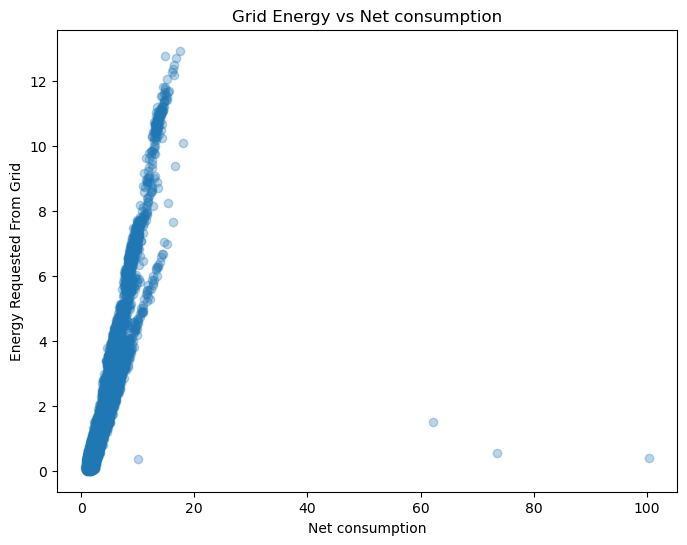

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["net_consumption"],
    df["EnergyRequestedFromGrid_kW_"],
    alpha=0.3
)

plt.xlabel("Net consumption")
plt.ylabel("Energy Requested From Grid")
plt.title("Grid Energy vs Net consumption")

plt.show()

In [9]:
df[[
    "EnergyRequestedFromGrid_kW_",
    "appliance_sum",
    "net_consumption"
]].corr()

,EnergyRequestedFromGrid_kW_,appliance_sum,net_consumption
EnergyRequestedFromGrid_kW_,1.000000,0.871446,0.877223
appliance_sum,0.871446,1.000000,0.995851
net_consumption,0.877223,0.995851,1.000000


### Removing null values & dealing with outliers ###

In [10]:
#How many inf values we have in the dataset
np.isinf(df.select_dtypes(include=np.number)).sum()

EnergyRequestedFromGrid_kW_     0
VentilationAndAC_kW_            0
CentralHeating_kW_              0
Dishwasher_kW_                  1
UnderFloorHeater_kW_            0
ElectricRadiator_kW_            0
HomeOffice_kW_                  0
Fridge_kW_                      0
CellarSumpPump_kW_              0
GarageDoor_kW_                  0
Oven_kW_                        0
CeramicHob_kW_                  0
RadonLevel_Bqm3                 0
Kettle_kW_                      1
MechanicalLoftVentilator_kW_    0
ShowerPump_kW_                  0
Microwave_kW_                   0
LivingRoom_kW_                  0
Solar_kW_                       0
temperature                     0
humidity                        0
visibility                      0
apparentTemperature             0
pressure                        0
windSpeed                       0
windBearing                     0
precipIntensity                 0
dewPoint                        0
precipProbability               0
appliance_sum 

In [11]:
pd.set_option('display.max_columns', None)
df.loc[[35041, 18894, 35949, 22467, 7677]]

,EnergyRequestedFromGrid_kW_,VentilationAndAC_kW_,CentralHeating_kW_,Dishwasher_kW_,UnderFloorHeater_kW_,ElectricRadiator_kW_,HomeOffice_kW_,Fridge_kW_,CellarSumpPump_kW_,GarageDoor_kW_,Oven_kW_,CeramicHob_kW_,RadonLevel_Bqm3,Kettle_kW_,MechanicalLoftVentilator_kW_,ShowerPump_kW_,Microwave_kW_,LivingRoom_kW_,Solar_kW_,temperature,humidity,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability,WeatherIcon,appliance_sum,net_consumption
35041,0.503046,0.112831,0.430023,inf,0.042898,0.250960,0.106925,0.150007,0.152307,0.056283,0.060306,0.051361,47.976911,0.036398,0.147996,0.066388,0.132791,0.022459,0.253454,81.637642,0.561337,10.073505,82.994487,1013.153705,6.303280,307.097459,0.273098,63.598069,0.00,clear-day,inf,inf
18894,0.515479,0.085589,0.477244,0.017948,0.204757,0.124057,0.207779,0.157851,0.250632,0.138181,0.078381,0.085215,0.034564,inf,0.055485,0.017098,0.071473,0.088132,0.032097,48.589527,0.580140,10.077913,42.307428,1007.574060,16.869959,287.066907,0.046219,28.344896,0.00,partly-cloudy-day,inf,inf
35949,0.394679,0.078579,0.413807,0.039593,0.161309,0.181112,0.159601,0.151039,0.074640,98.627538,0.103516,0.000507,36.021768,0.086785,0.195562,0.110851,0.059097,0.005278,0.099554,65.153319,0.838990,10.110868,65.209941,1027.782904,4.937778,216.111330,0.113417,52.416115,0.00,clear-day,100.448812,100.349258
22467,0.551070,0.017829,0.503829,0.069514,0.403228,0.199653,71.667093,0.018546,0.024768,0.039427,0.051801,0.013851,1.841852,0.136205,0.063497,0.097772,0.130957,0.069300,0.008834,61.934775,0.611732,10.009547,62.033182,1013.941339,12.894704,319.075372,0.078556,40.366046,0.00,clear-day,73.507272,73.498437
7677,1.504733,58.766005,1.501390,0.082074,0.145372,0.145010,0.089299,0.196288,0.027602,0.140274,0.086124,0.430239,4.586658,0.086721,0.050641,0.018391,0.056197,0.334509,0.046540,58.463817,0.987072,7.613531,58.598139,992.002845,18.775481,186.165799,0.077441,54.807495,0.72,rain,62.156135,62.109595


In [12]:
#How many rows contain at least one NaN value
df.isna().any(axis=1).sum()

np.int64(20)

In [13]:
# Remove inf and NaN rows
# Original number of rows: 50391
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df= df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50369 entries, 0 to 50390
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   EnergyRequestedFromGrid_kW_   50369 non-null  float64
 1   VentilationAndAC_kW_          50369 non-null  float64
 2   CentralHeating_kW_            50369 non-null  float64
 3   Dishwasher_kW_                50369 non-null  float64
 4   UnderFloorHeater_kW_          50369 non-null  float64
 5   ElectricRadiator_kW_          50369 non-null  float64
 6   HomeOffice_kW_                50369 non-null  float64
 7   Fridge_kW_                    50369 non-null  float64
 8   CellarSumpPump_kW_            50369 non-null  float64
 9   GarageDoor_kW_                50369 non-null  float64
 10  Oven_kW_                      50369 non-null  float64
 11  CeramicHob_kW_                50369 non-null  float64
 12  RadonLevel_Bqm3               50369 non-null  float64
 13  Kettle

In [14]:
bad_rows = [7677, 22467, 35949]

df = df.drop(index=bad_rows)

In [15]:
top_heating_idx = df["CentralHeating_kW_"].sort_values(ascending=False).head(20).index

df.loc[top_heating_idx, [
    "CentralHeating_kW_",
    "temperature",
    "apparentTemperature",
    "windSpeed",
    "windBearing",
    "WeatherIcon"
]]

,CentralHeating_kW_,temperature,apparentTemperature,windSpeed,windBearing,WeatherIcon
32496,12.900587,63.967794,64.041853,4.341037,293.038502,clear-night
29754,12.810154,65.502327,65.547632,1.244183,1.053060,rain
32503,12.705088,63.224360,63.246575,5.525649,296.200818,clear-night
30476,12.465273,80.184908,80.855181,8.846939,289.104764,clear-day
36366,12.269318,71.270903,71.280938,2.579375,192.025538,rain
34793,12.227745,67.447736,67.427876,4.744146,3.015659,clear-night
32481,12.125663,66.728382,66.860675,6.554442,343.033306,rain
28207,11.990187,73.731303,73.809757,5.028219,189.108225,clear-night
32488,11.789268,65.672221,65.662798,4.635060,309.116380,partly-cloudy-night
32494,11.763488,63.996663,63.992418,4.346232,293.063733,clear-night


### KPI's from the dataset ###

In [16]:
df.describe()

,EnergyRequestedFromGrid_kW_,VentilationAndAC_kW_,CentralHeating_kW_,Dishwasher_kW_,UnderFloorHeater_kW_,ElectricRadiator_kW_,HomeOffice_kW_,Fridge_kW_,CellarSumpPump_kW_,GarageDoor_kW_,Oven_kW_,CeramicHob_kW_,RadonLevel_Bqm3,Kettle_kW_,MechanicalLoftVentilator_kW_,ShowerPump_kW_,Microwave_kW_,LivingRoom_kW_,Solar_kW_,temperature,humidity,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability,appliance_sum,net_consumption
count,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,5.036600e+04,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000
mean,0.940555,0.156250,0.940728,0.111099,0.179277,0.218233,0.160595,0.143242,0.122391,0.093713,0.082409,0.087239,38.244233,7.951204e-02,0.137692,0.096622,0.090620,0.115445,0.155992,50.820772,0.744112,9.464362,48.342016,1016.381790,6.728969,202.475631,0.082736,38.770803,0.056499,2.815066,2.659073
std,1.059878,0.141943,1.060366,0.199530,0.178546,0.189752,0.120514,0.097473,0.084001,0.061205,0.064964,0.104381,64.324201,6.017487e-02,0.205226,0.154133,0.115072,0.113171,0.141831,19.114935,0.203756,29.510249,22.029265,7.895075,3.982791,106.548250,0.061103,19.088207,0.165889,1.429006,1.438590
min,0.004949,0.000008,0.001279,0.000002,0.001151,0.032973,0.014322,0.001204,0.004566,0.011094,0.000274,0.000020,0.013540,2.143018e-07,0.002273,0.000742,0.002946,0.000971,0.000213,-12.609150,0.132636,0.272273,-32.075540,986.416819,0.000367,0.000087,0.000004,-27.230295,0.000000,0.827345,0.703445
25%,0.447762,0.054126,0.448400,0.033926,0.067455,0.108686,0.084843,0.064708,0.053993,0.045439,0.032243,0.032836,1.745166,3.137499e-02,0.066089,0.033446,0.036093,0.038850,0.053307,35.854006,0.591941,9.499247,31.150977,1011.372207,3.744741,148.096331,0.034248,24.645578,0.000000,2.014623,1.844159
50%,0.651755,0.108187,0.652645,0.071687,0.117971,0.152813,0.128995,0.139712,0.107805,0.081312,0.068929,0.068912,2.223950,6.741287e-02,0.105889,0.070082,0.071781,0.081189,0.109148,50.419941,0.761487,10.020757,50.412055,1016.607953,6.006585,208.235495,0.070739,39.094611,0.000000,2.399106,2.250689
75%,1.056405,0.205421,1.055621,0.124593,0.200720,0.222640,0.189354,0.198691,0.175254,0.128815,0.118445,0.118002,41.896167,1.148927e-01,0.160462,0.119100,0.119796,0.143767,0.204607,66.342533,0.911730,10.080445,66.338368,1021.554725,9.012837,295.031298,0.118564,54.868045,0.000000,3.086537,2.961501
max,12.924612,0.784988,12.900587,1.690084,2.064746,1.046913,0.853720,0.922601,1.391359,1.022935,1.142992,8.598130,295.320011,4.367488e-01,6.752732,1.944524,2.212184,0.732047,0.849880,93.868989,1.319166,6622.234211,101.205179,1042.624967,23.083469,359.354458,0.482160,75.548921,0.840000,18.179342,17.978287


In [17]:
df[appliance_cols].describe(percentiles=[0.5, 0.75, 0.95, 0.99])

,VentilationAndAC_kW_,CentralHeating_kW_,Dishwasher_kW_,UnderFloorHeater_kW_,ElectricRadiator_kW_,HomeOffice_kW_,Fridge_kW_,CellarSumpPump_kW_,GarageDoor_kW_,Oven_kW_,CeramicHob_kW_,Kettle_kW_,MechanicalLoftVentilator_kW_,ShowerPump_kW_,Microwave_kW_,LivingRoom_kW_
count,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,50366.000000,5.036600e+04,50366.000000,50366.000000,50366.000000,50366.000000
mean,0.156250,0.940728,0.111099,0.179277,0.218233,0.160595,0.143242,0.122391,0.093713,0.082409,0.087239,7.951204e-02,0.137692,0.096622,0.090620,0.115445
std,0.141943,1.060366,0.199530,0.178546,0.189752,0.120514,0.097473,0.084001,0.061205,0.064964,0.104381,6.017487e-02,0.205226,0.154133,0.115072,0.113171
min,0.000008,0.001279,0.000002,0.001151,0.032973,0.014322,0.001204,0.004566,0.011094,0.000274,0.000020,2.143018e-07,0.002273,0.000742,0.002946,0.000971
50%,0.108187,0.652645,0.071687,0.117971,0.152813,0.128995,0.139712,0.107805,0.081312,0.068929,0.068912,6.741287e-02,0.105889,0.070082,0.071781,0.081189
75%,0.205421,1.055621,0.124593,0.200720,0.222640,0.189354,0.198691,0.175254,0.128815,0.118445,0.118002,1.148927e-01,0.160462,0.119100,0.119796,0.143767
95%,0.472352,2.324573,0.227683,0.585935,0.728373,0.475414,0.298975,0.274193,0.211080,0.202387,0.206137,1.961855e-01,0.320589,0.211520,0.205250,0.392254
99%,0.576929,6.625358,1.408642,0.705344,0.841372,0.626832,0.402950,0.352060,0.273062,0.271010,0.337942,2.570302e-01,0.523573,0.847045,0.290387,0.491576
max,0.784988,12.900587,1.690084,2.064746,1.046913,0.853720,0.922601,1.391359,1.022935,1.142992,8.598130,4.367488e-01,6.752732,1.944524,2.212184,0.732047


In [18]:
df.corr(numeric_only=True)["EnergyRequestedFromGrid_kW_"].sort_values(ascending=False)

EnergyRequestedFromGrid_kW_     1.000000
CentralHeating_kW_              0.996738
net_consumption                 0.950930
appliance_sum                   0.945439
ElectricRadiator_kW_            0.461740
UnderFloorHeater_kW_            0.298150
Dishwasher_kW_                  0.187003
MechanicalLoftVentilator_kW_    0.177984
LivingRoom_kW_                  0.171622
ShowerPump_kW_                  0.149980
HomeOffice_kW_                  0.129526
Fridge_kW_                      0.120897
Microwave_kW_                   0.094746
CellarSumpPump_kW_              0.085648
CeramicHob_kW_                  0.068300
windBearing                     0.014512
dewPoint                        0.014298
humidity                        0.011731
GarageDoor_kW_                  0.011404
Oven_kW_                        0.010716
pressure                        0.009338
temperature                     0.008093
apparentTemperature             0.003350
precipIntensity                 0.001264
visibility      

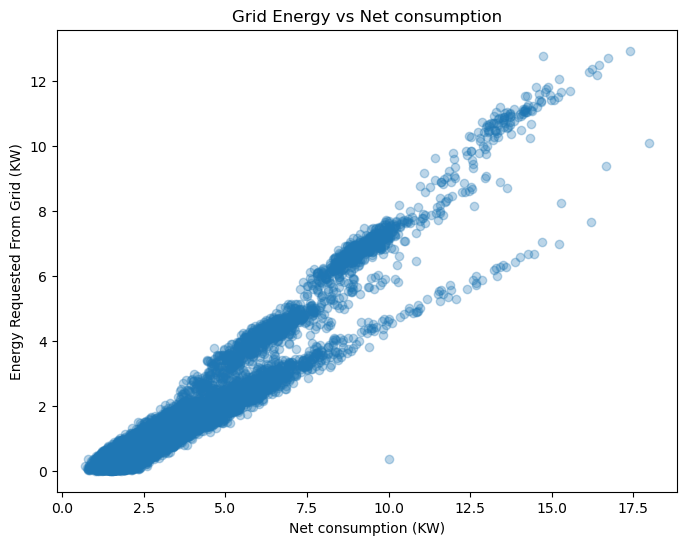

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["net_consumption"],
    df["EnergyRequestedFromGrid_kW_"],
    alpha=0.3
)

plt.xlabel("Net consumption (KW)")
plt.ylabel("Energy Requested From Grid (KW)")
plt.title("Grid Energy vs Net consumption")

plt.show()

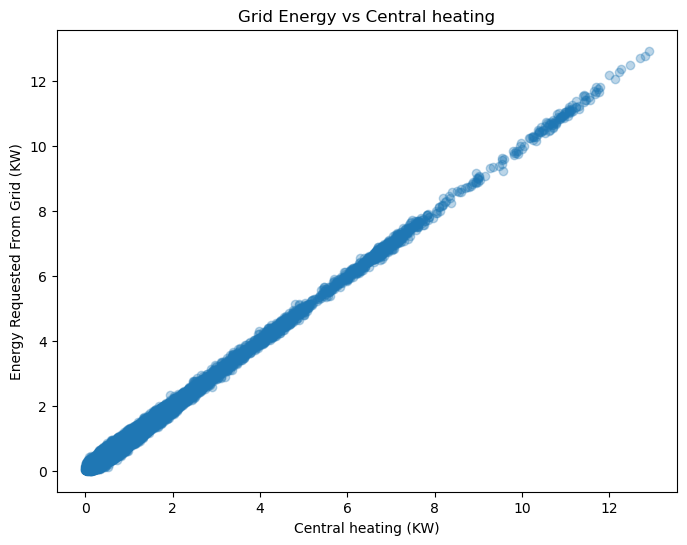

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["CentralHeating_kW_"],
    df["EnergyRequestedFromGrid_kW_"],
    alpha=0.3
)

plt.xlabel("Central heating (KW)")
plt.ylabel("Energy Requested From Grid (KW)")
plt.title("Grid Energy vs Central heating")

plt.show()

In [20]:
solar_favorable = [
    "clear-day",
    "partly-cloudy-day"
]

df["SolarCondition"] = df["WeatherIcon"].apply(
    lambda x: "Favorable" if x in solar_favorable else "Unfavorable"
)

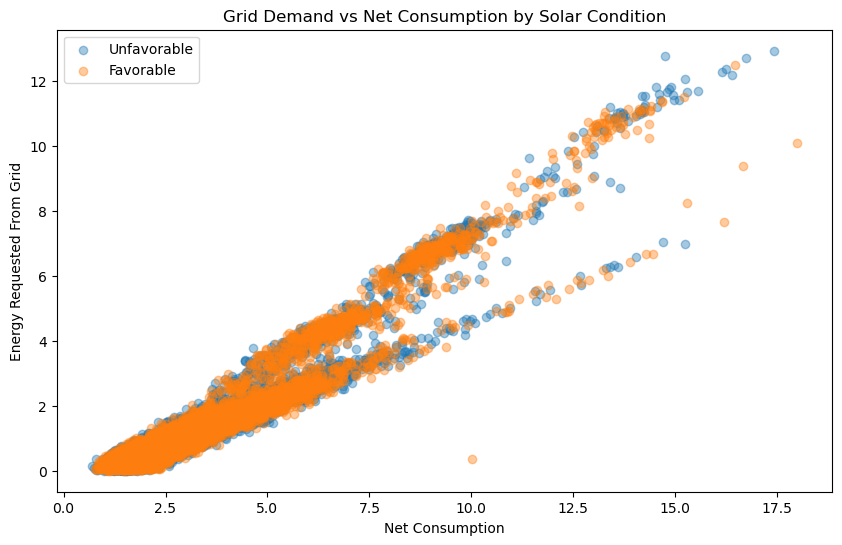

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for condition in df["SolarCondition"].unique():
    subset = df[df["SolarCondition"] == condition]
    
    plt.scatter(
        subset["net_consumption"],
        subset["EnergyRequestedFromGrid_kW_"],
        alpha=0.4,
        label=condition
    )

plt.xlabel("Net Consumption")
plt.ylabel("Energy Requested From Grid")
plt.title("Grid Demand vs Net Consumption by Solar Condition")

plt.legend()

plt.show()

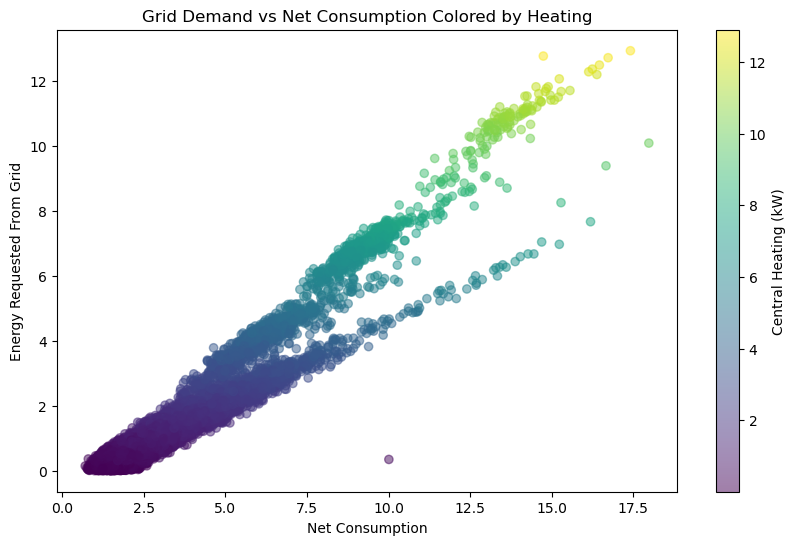

In [22]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["net_consumption"],
    df["EnergyRequestedFromGrid_kW_"],
    c=df["CentralHeating_kW_"],
    alpha=0.5
)

plt.colorbar(scatter, label="Central Heating (kW)")

plt.xlabel("Net Consumption")
plt.ylabel("Energy Requested From Grid")
plt.title("Grid Demand vs Net Consumption Colored by Heating")

plt.show()

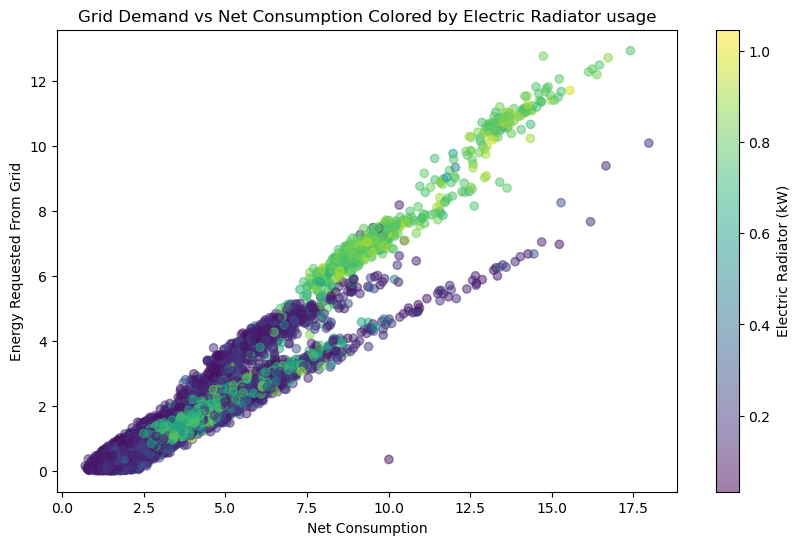

In [23]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["net_consumption"],
    df["EnergyRequestedFromGrid_kW_"],
    c=df["ElectricRadiator_kW_"],
    alpha=0.5
)

plt.colorbar(scatter, label="Electric Radiator (kW)")

plt.xlabel("Net Consumption")
plt.ylabel("Energy Requested From Grid")
plt.title("Grid Demand vs Net Consumption Colored by Electric Radiator usage")

plt.show()

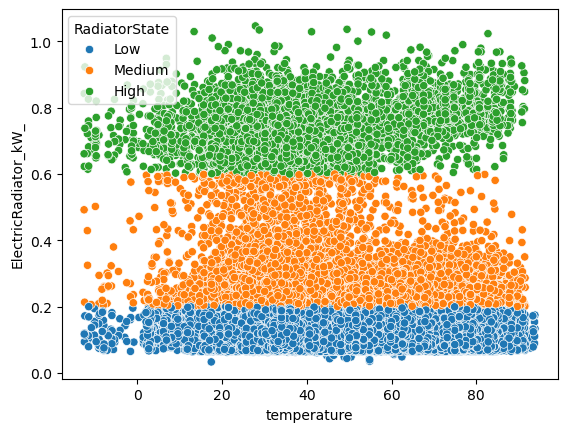

In [24]:
import seaborn as sns

df["RadiatorState"] = pd.cut( 
    df["ElectricRadiator_kW_"], 
    bins=[0, 0.2, 0.6, df["ElectricRadiator_kW_"].max()], 
    labels=["Low", "Medium", "High"] )

sns.scatterplot(
    data=df,
    x="temperature",
    y="ElectricRadiator_kW_",
    hue="RadiatorState"
)
plt.show()

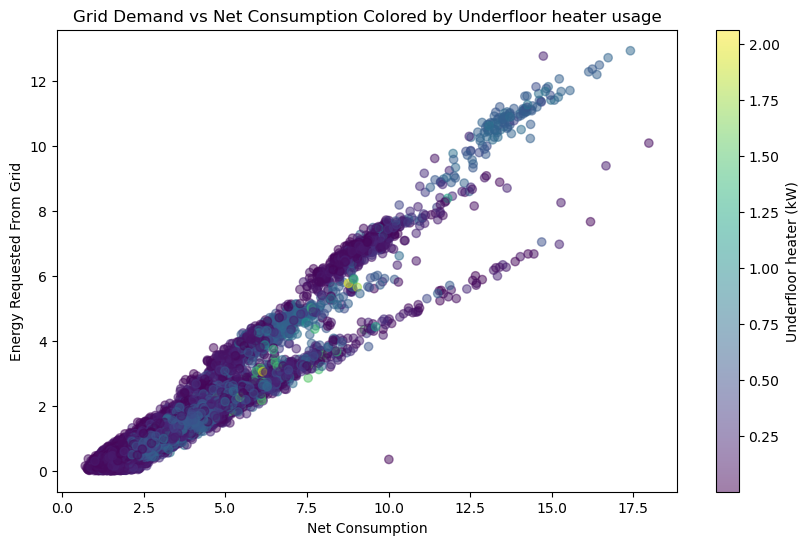

In [25]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["net_consumption"],
    df["EnergyRequestedFromGrid_kW_"],
    c=df["UnderFloorHeater_kW_"],
    alpha=0.5
)

plt.colorbar(scatter, label="Underfloor heater (kW)")

plt.xlabel("Net Consumption")
plt.ylabel("Energy Requested From Grid")
plt.title("Grid Demand vs Net Consumption Colored by Underfloor heater usage")

plt.show()

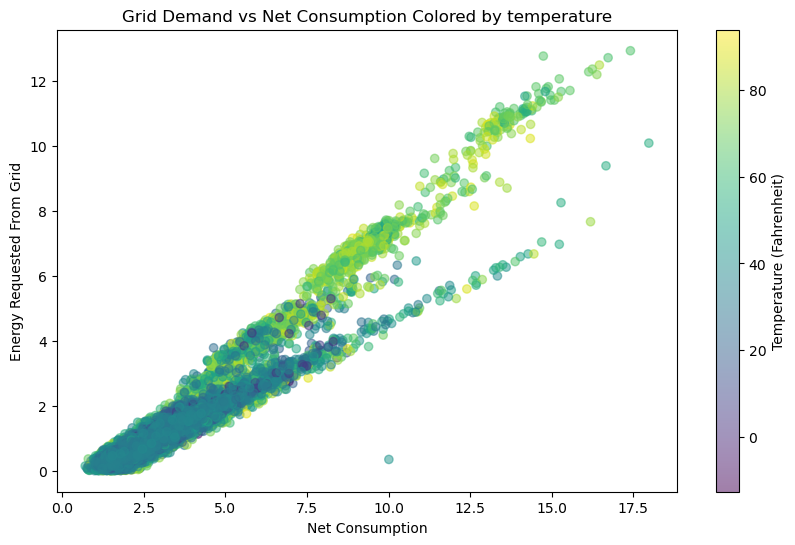

In [26]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["net_consumption"],
    df["EnergyRequestedFromGrid_kW_"],
    c=df["temperature"],
    alpha=0.5
)

plt.colorbar(scatter, label="Temperature (Fahrenheit)")

plt.xlabel("Net Consumption")
plt.ylabel("Energy Requested From Grid")
plt.title("Grid Demand vs Net Consumption Colored by temperature")

plt.show()

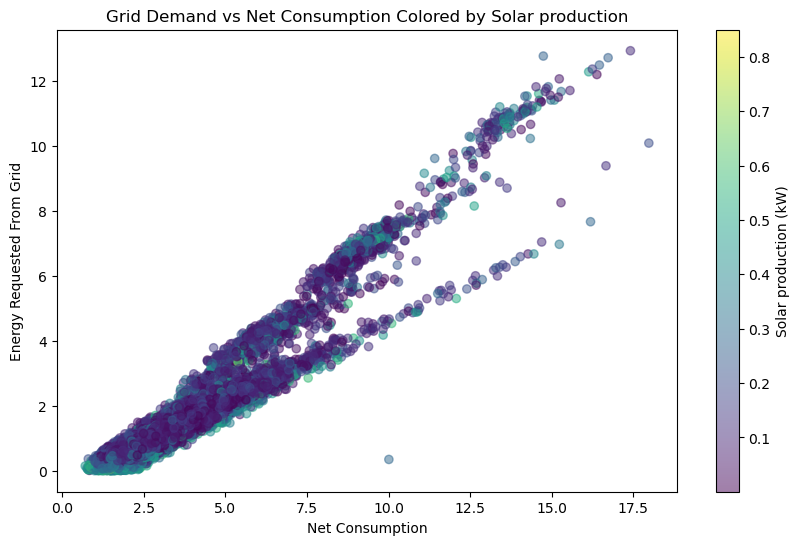

In [27]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["net_consumption"],
    df["EnergyRequestedFromGrid_kW_"],
    c=df["Solar_kW_"],
    alpha=0.5
)

plt.colorbar(scatter, label="Solar production (kW)")

plt.xlabel("Net Consumption")
plt.ylabel("Energy Requested From Grid")
plt.title("Grid Demand vs Net Consumption Colored by Solar production")

plt.show()

In [28]:
df["CentralHeating_kW_"].describe()

count    50366.000000
mean         0.940728
std          1.060366
min          0.001279
25%          0.448400
50%          0.652645
75%          1.055621
max         12.900587
Name: CentralHeating_kW_, dtype: float64

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA containing the target
features = [
    "CentralHeating_kW_",
    "ElectricRadiator_kW_",
    "UnderFloorHeater_kW_",
    "Solar_kW_",
    "temperature",
    "humidity",
    "EnergyRequestedFromGrid_kW_"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

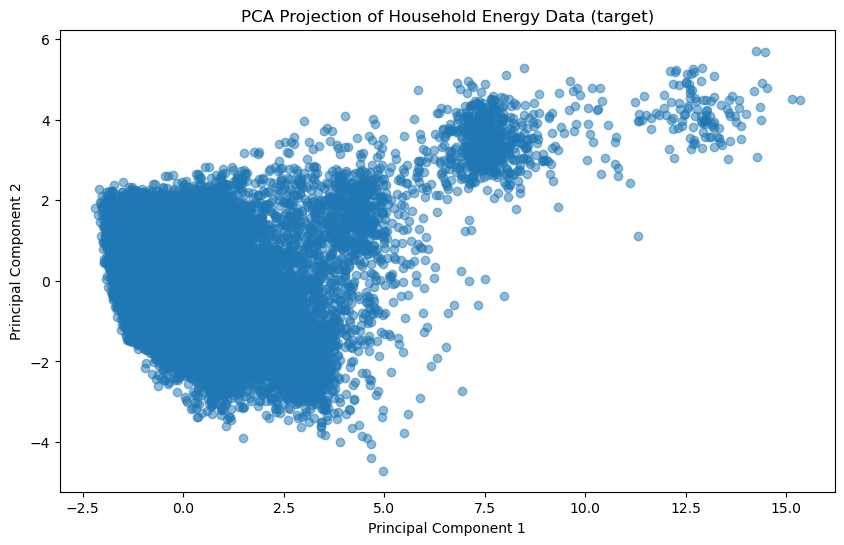

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],   # Principal Component 1
    X_pca[:, 1],   # Principal Component 2
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Household Energy Data (target)")

plt.show()

In [31]:
# PCA NOT containing the target
features_noTarget = [
    "CentralHeating_kW_",
    "ElectricRadiator_kW_",
    "UnderFloorHeater_kW_",
    "Solar_kW_",
    "temperature",
    "humidity",
]

X = df[features_noTarget]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1:{pca.components_[0]}")
print(f"PC2:{pca.components_[1]}")

PC1:[ 0.53808328  0.56490433  0.48359906 -0.19314725 -0.34658024 -0.00759707]
PC2:[ 0.37849323  0.16779539 -0.17152881 -0.06656648  0.67172855 -0.58610162]


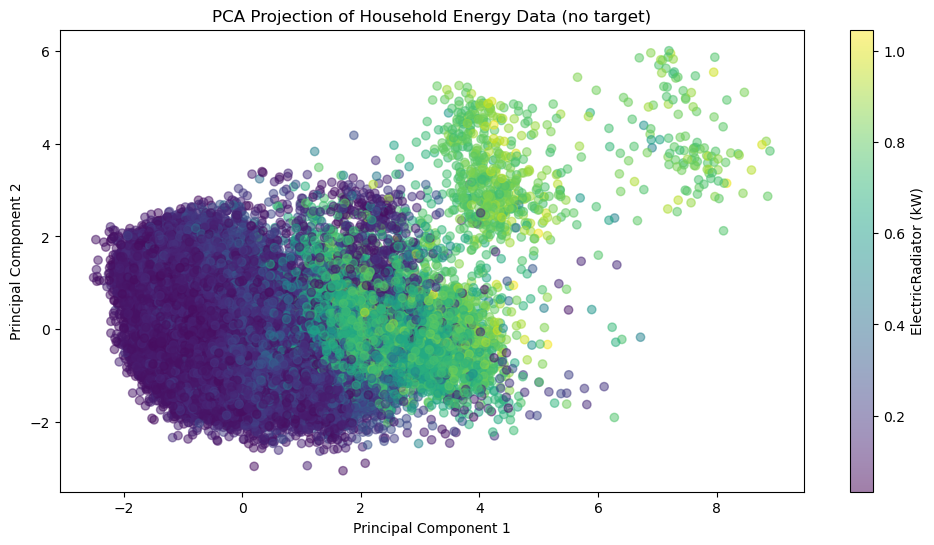

In [32]:
plt.figure(figsize=(12, 6))

scatter = plt.scatter(
    X_pca[:, 0],   # Principal Component 1
    X_pca[:, 1],   # Principal Component 2
    alpha=0.5,
    c = df["ElectricRadiator_kW_"]
)

plt.colorbar(scatter, label="ElectricRadiator (kW)")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Household Energy Data (no target)")

plt.show()

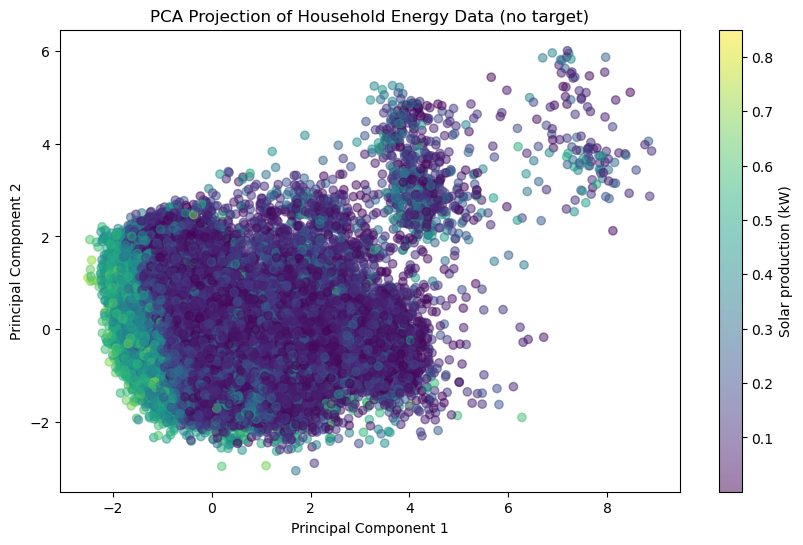

In [33]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca[:, 0],   # Principal Component 1
    X_pca[:, 1],   # Principal Component 2
    alpha=0.5,
    c = df["Solar_kW_"]
)

plt.colorbar(scatter, label="Solar production (kW)")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Household Energy Data (no target)")

plt.show()

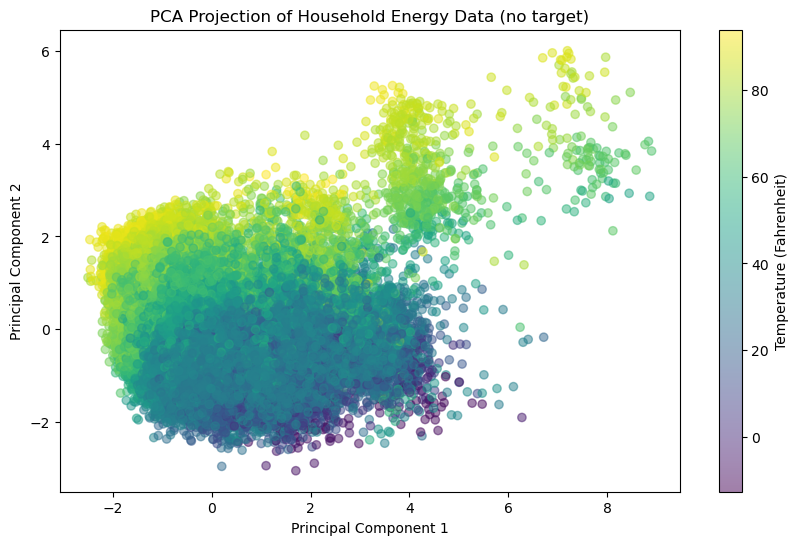

In [34]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca[:, 0],   # Principal Component 1
    X_pca[:, 1],   # Principal Component 2
    alpha=0.5,
    c = df["temperature"]
)

plt.colorbar(scatter, label="Temperature (Fahrenheit)")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Household Energy Data (no target)")

plt.show()

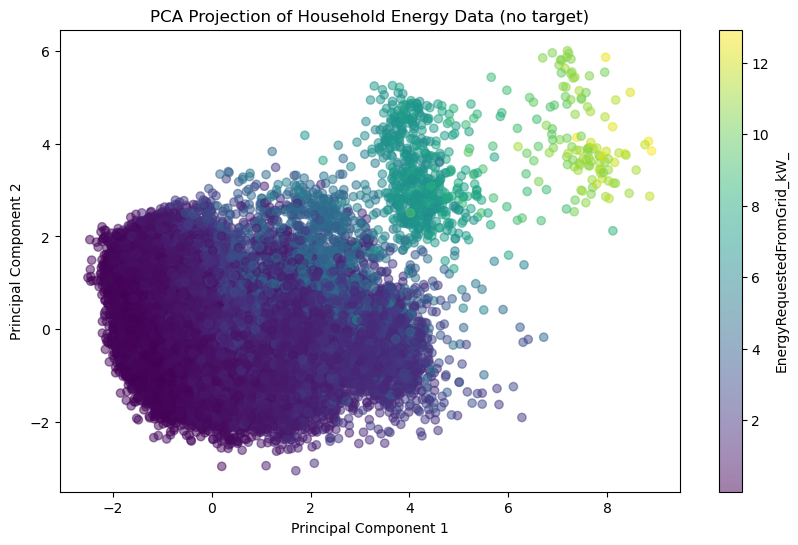

In [35]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca[:, 0],   # Principal Component 1
    X_pca[:, 1],   # Principal Component 2
    alpha=0.5,
    c = df["EnergyRequestedFromGrid_kW_"]
)

plt.colorbar(scatter, label="EnergyRequestedFromGrid_kW_")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Household Energy Data (no target)")

plt.show()

In [36]:
pca.explained_variance_ratio_

array([0.29834208, 0.18097254])